In [1]:
import pandas as pd
import numpy as np
from mlxtend.plotting import plot_decision_regions

In [2]:
df= pd.DataFrame()

In [3]:
df['X1'] = [1,2,3,4,5,6,6,7,9,9]
df['X2'] = [5,3,6,8,1,9,5,8,9,2]
df['label'] = [1,1,0,1,0,1,0,1,0,0]

In [4]:
df

,X1,X2,label
0,1,5,1
1,2,3,1
2,3,6,0
3,4,8,1
4,5,1,0
5,6,9,1
6,6,5,0
7,7,8,1
8,9,9,0
9,9,2,0


<Axes: xlabel='X1', ylabel='X2'>

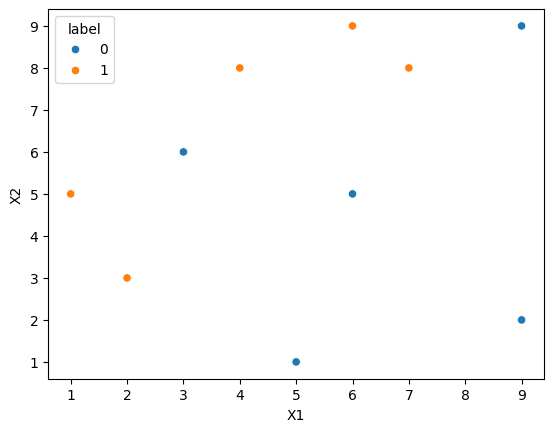

In [5]:
import seaborn as sns
sns.scatterplot(x=df['X1'], y=df['X2'], hue=df['label'])

In [6]:
df['weights'] = 1/df.shape[0]

In [7]:
df

,X1,X2,label,weights
0,1,5,1,0.1
1,2,3,1,0.1
2,3,6,0,0.1
3,4,8,1,0.1
4,5,1,0,0.1
5,6,9,1,0.1
6,6,5,0,0.1
7,7,8,1,0.1
8,9,9,0,0.1
9,9,2,0,0.1


In [8]:
from sklearn.tree import DecisionTreeClassifier

In [9]:
dt1 = DecisionTreeClassifier(max_depth=1)

In [10]:
x = df.iloc[:,0:2].values
y = df.iloc[:,2].values

In [11]:
# step 2 - train 1st model
dt1.fit(x,y)

DecisionTreeClassifier(max_depth=1)

[Text(0.5, 0.75, 'x[1] <= 2.5\ngini = 0.5\nsamples = 10\nvalue = [5, 5]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.469\nsamples = 8\nvalue = [3, 5]'),
 Text(0.625, 0.5, '  False')]

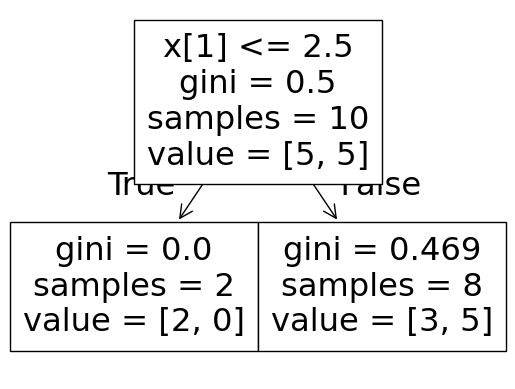

In [12]:
from sklearn.tree import plot_tree
plot_tree(dt1)

<Axes: >

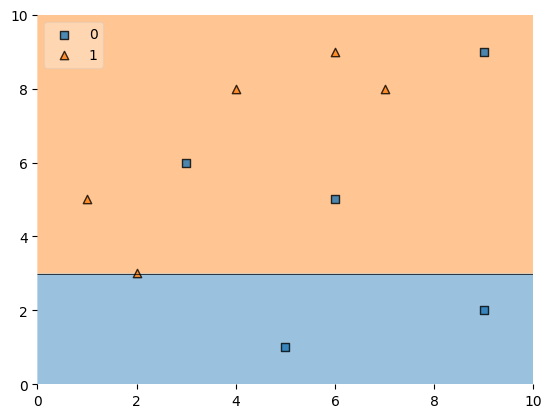

In [13]:
plot_decision_regions(x,y,clf=dt1, legend=2)

In [14]:
df['y_pred'] = dt1.predict(x)

In [15]:
df


,X1,X2,label,weights,y_pred
0,1,5,1,0.1,1
1,2,3,1,0.1,1
2,3,6,0,0.1,1
3,4,8,1,0.1,1
4,5,1,0,0.1,0
5,6,9,1,0.1,1
6,6,5,0,0.1,1
7,7,8,1,0.1,1
8,9,9,0,0.1,1
9,9,2,0,0.1,0


In [48]:
def calculate_model_weight(error):
  return 0.5 * np.log((1-error)/(error+0.000000001))

In [49]:
# step 3- calculate model weight
alpha1 = calculate_model_weight(0.3)
alpha1

np.float64(0.42364892852693514)

In [21]:
# step 4 - update weights
def update_row_weights(row, alpha=0.423):
  if row['label'] == row['y_pred']:
    return row['weights'] * np.exp(-alpha)
  else:
    return row['weights'] * np.exp(alpha)


In [22]:
df['updated_weights'] = df.apply(update_row_weights,axis=1)

In [23]:
df

,X1,X2,label,weights,y_pred,updated_weights
0,1,5,1,0.1,1,0.065508
1,2,3,1,0.1,1,0.065508
2,3,6,0,0.1,1,0.152653
3,4,8,1,0.1,1,0.065508
4,5,1,0,0.1,0,0.065508
5,6,9,1,0.1,1,0.065508
6,6,5,0,0.1,1,0.152653
7,7,8,1,0.1,1,0.065508
8,9,9,0,0.1,1,0.152653
9,9,2,0,0.1,0,0.065508


In [24]:
df['updated_weights'].sum()

np.float64(0.9165153319682015)

In [25]:
df['normalized_weights'] = df['updated_weights']/df['updated_weights'].sum()

In [26]:
df

,X1,X2,label,weights,y_pred,updated_weights,normalized_weights
0,1,5,1,0.1,1,0.065508,0.071475
1,2,3,1,0.1,1,0.065508,0.071475
2,3,6,0,0.1,1,0.152653,0.166559
3,4,8,1,0.1,1,0.065508,0.071475
4,5,1,0,0.1,0,0.065508,0.071475
5,6,9,1,0.1,1,0.065508,0.071475
6,6,5,0,0.1,1,0.152653,0.166559
7,7,8,1,0.1,1,0.065508,0.071475
8,9,9,0,0.1,1,0.152653,0.166559
9,9,2,0,0.1,0,0.065508,0.071475


In [27]:
df['normalized_weights'].sum()

np.float64(1.0)

In [28]:
df['cumsum_upper'] = np.cumsum(df['normalized_weights'])

In [29]:
df['cumsum_lower'] = df['cumsum_upper'] - df['normalized_weights']

In [30]:
df[['X1','X2','label','weights','y_pred','updated_weights','cumsum_lower','cumsum_upper']]

,X1,X2,label,weights,y_pred,updated_weights,cumsum_lower,cumsum_upper
0,1,5,1,0.1,1,0.065508,0.000000,0.071475
1,2,3,1,0.1,1,0.065508,0.071475,0.142950
2,3,6,0,0.1,1,0.152653,0.142950,0.309508
3,4,8,1,0.1,1,0.065508,0.309508,0.380983
4,5,1,0,0.1,0,0.065508,0.380983,0.452458
5,6,9,1,0.1,1,0.065508,0.452458,0.523933
6,6,5,0,0.1,1,0.152653,0.523933,0.690492
7,7,8,1,0.1,1,0.065508,0.690492,0.761967
8,9,9,0,0.1,1,0.152653,0.761967,0.928525
9,9,2,0,0.1,0,0.065508,0.928525,1.000000


In [34]:
def create_new_dataset(df):

  indices = []

  for i in range(df.shape[0]):
    a = np.random.random()
    for index, row in df.iterrows():
      if row['cumsum_upper'] > a and a > row['cumsum_lower']:
        indices.append(index)
  return indices

In [35]:
index_values = create_new_dataset(df)

index_values

[7, 0, 8, 1, 1, 1, 9, 1, 7, 9]

In [37]:
second_df = df.iloc[index_values,[0,1,2,3]]

second_df

,X1,X2,label,weights
7,7,8,1,0.1
0,1,5,1,0.1
8,9,9,0,0.1
1,2,3,1,0.1
1,2,3,1,0.1
1,2,3,1,0.1
9,9,2,0,0.1
1,2,3,1,0.1
7,7,8,1,0.1
9,9,2,0,0.1


In [38]:
dt2 = DecisionTreeClassifier(max_depth=1)

In [39]:
x = second_df.iloc[:,0:2].values
y = second_df.iloc[:,2].values

In [40]:
dt2.fit(x,y)

DecisionTreeClassifier(max_depth=1)

[Text(0.5, 0.75, 'x[0] <= 8.0\ngini = 0.42\nsamples = 10\nvalue = [3, 7]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 7\nvalue = [0, 7]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.0\nsamples = 3\nvalue = [3, 0]'),
 Text(0.625, 0.5, '  False')]

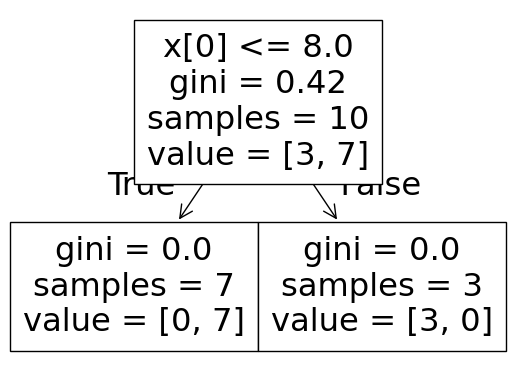

In [41]:
plot_tree(dt2)

<Axes: >

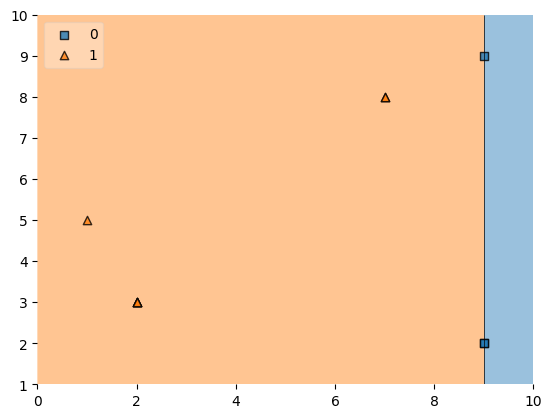

In [42]:
plot_decision_regions(x,y,clf=dt2, legend=2)

In [43]:
second_df['y_pred'] = dt2.predict(x)

In [44]:
second_df

,X1,X2,label,weights,y_pred
7,7,8,1,0.1,1
0,1,5,1,0.1,1
8,9,9,0,0.1,0
1,2,3,1,0.1,1
1,2,3,1,0.1,1
1,2,3,1,0.1,1
9,9,2,0,0.1,0
1,2,3,1,0.1,1
7,7,8,1,0.1,1
9,9,2,0,0.1,0


In [51]:
alpha2 = calculate_model_weight(0)

alpha2

np.float64(10.361632918473205)

In [52]:
# step 4 - update weights
def update_row_weight(row, alpha = 10.361):
  if row['label'] == row['y_pred']:
    return row['weights'] * np.exp(-alpha)
  else:
    return row['weights'] * np.exp(alpha)


In [53]:
second_df['updated_weights'] = second_df.apply(update_row_weight,axis=1)

In [56]:
second_df

,X1,X2,label,weights,y_pred,updated_weights
7,7,8,1,0.1,1,0.000003
0,1,5,1,0.1,1,0.000003
8,9,9,0,0.1,0,0.000003
1,2,3,1,0.1,1,0.000003
1,2,3,1,0.1,1,0.000003
1,2,3,1,0.1,1,0.000003
9,9,2,0,0.1,0,0.000003
1,2,3,1,0.1,1,0.000003
7,7,8,1,0.1,1,0.000003
9,9,2,0,0.1,0,0.000003


In [57]:
second_df['normalized_weights'] = second_df['updated_weights'] / second_df['updated_weights'].sum()

In [58]:
second_df

,X1,X2,label,weights,y_pred,updated_weights,normalized_weights
7,7,8,1,0.1,1,0.000003,0.1
0,1,5,1,0.1,1,0.000003,0.1
8,9,9,0,0.1,0,0.000003,0.1
1,2,3,1,0.1,1,0.000003,0.1
1,2,3,1,0.1,1,0.000003,0.1
1,2,3,1,0.1,1,0.000003,0.1
9,9,2,0,0.1,0,0.000003,0.1
1,2,3,1,0.1,1,0.000003,0.1
7,7,8,1,0.1,1,0.000003,0.1
9,9,2,0,0.1,0,0.000003,0.1


In [59]:
second_df['cumsum_upper'] = np.cumsum(second_df['normalized_weights'])

In [60]:
second_df['cumsum_lower'] = second_df['cumsum_upper'] - second_df['normalized_weights']

Predicition

In [61]:
query = np.array([1,5]).reshape(1,2)
dt1.predict(query)

array([1])

In [62]:
dt2.predict(query)

array([1])

In [63]:
alpha1 * 1 + alpha2 * 1


np.float64(10.78528184700014)

In [64]:
np.sign(10.785)

np.float64(1.0)